In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("52-urban_pedestrian_locations_with_labels.csv")

In [3]:
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


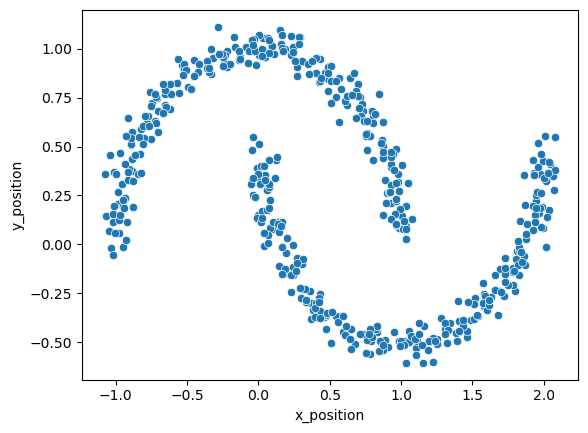

In [6]:
sns.scatterplot(data=df, x='x_position', y='y_position')
plt.show()

In [7]:
df.drop('true_cluster', inplace=True, axis=1)

In [8]:
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [9]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(df)

In [10]:
from sklearn.cluster import DBSCAN

In [11]:
db = DBSCAN()

eps : float, default=0.5 The maximum distance between two samples for one to be considered as in the neighborhood of the other. This is not a maximum bound on the distances of points within a cluster. This is the most important DBSCAN parameter to choose appropriately for your data set and distance function.

min_samples : int, default=5 The number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself. If min_samples is set to a higher value, DBSCAN will find denser clusters, whereas if it is set to a lower value, the found clusters will be more sparse.

In [12]:
db.fit(X_scaled)

DBSCAN()

In [13]:
db.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

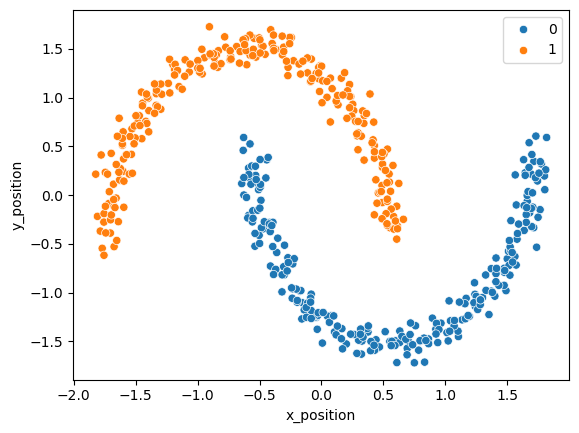

In [16]:
sns.scatterplot(data=pd.DataFrame(X_scaled, columns=df.columns), x='x_position', y='y_position', hue=db.labels_)
plt.show()

In [17]:
# hyperparameter tuning

In [18]:
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [4,5,6]

In [19]:
from sklearn.metrics import silhouette_score

In [23]:
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        db.fit(X_scaled)

        if len(set(db.labels_)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, db.labels_)

        results.append(
            {
                'eps' : eps,
                'min_samples' : min_samples,
                'Silhouette' : silhouette,
                'n_clusters': len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [24]:
results_df

,eps,min_samples,Silhouette,n_clusters
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2
16,0.6,5,0.389338,2
15,0.6,4,0.389338,2
14,0.5,6,0.389338,2
13,0.5,5,0.389338,2
12,0.5,4,0.389338,2
11,0.4,6,0.389338,2
17,0.6,6,0.389338,2
8,0.3,6,0.389338,2


# HDBScan
- DBScan'a göre farkı epsilon olmaması. Bu değeri kendisi belirliyor dinamik olarak.

In [25]:
from sklearn.cluster import HDBSCAN

In [26]:
hdb = HDBSCAN()

In [27]:
hdb.fit(X_scaled)

HDBSCAN()

In [29]:
hdb.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

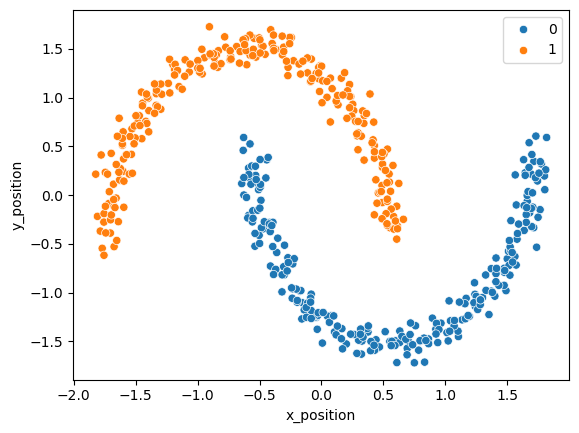

In [32]:
sns.scatterplot(data=pd.DataFrame(X_scaled, columns=df.columns), x="x_position", y="y_position", hue=hdb.labels_)
plt.show()

In [33]:
# hyperparameter tuning for hdbscan

In [34]:
min_cluster_size = [3,5,7,10]
min_samples = [None, 3,5,7]

In [36]:
results = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_samples=min_sample, min_cluster_size=min_cluster)
        hdb.fit(X_scaled)

        if len(set(hdb.labels_)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, hdb.labels_)

        results.append(
            {
                'min_cluster_size' : min_cluster,
                'min_samples' : min_sample,
                'Silhouette': silhouette,
                'n_clusters': len(set(hdb.labels_)) - (1 if -1 in hdb.labels_ else 0)
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [37]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters
2,3,5.0,0.389338,2
3,3,7.0,0.389338,2
4,5,NaN,0.389338,2
5,5,3.0,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
8,7,NaN,0.389338,2
9,7,3.0,0.389338,2
10,7,5.0,0.389338,2
11,7,7.0,0.389338,2
